# Movie Recommendation System Using K-Means Clustering.

## 1.Problem Statement
- With the exponential growth of digital streaming platforms such as Netflix, Amazon Prime, and Disney+, users are exposed to a massive library of movies. This abundance often leads to decision fatigue, making it difficult for users to discover relevant content.

- Traditional recommendation systems rely heavily on user history or collaborative filtering, which may not always be available for new users (cold start problem).

- Therefore, there is a need for a data-driven approach that groups similar movies based on intrinsic features such as genre, ratings, popularity, and duration, enabling efficient and meaningful recommendations without requiring user history.

## 2.Objectives 
- To group similar movies using K-Means clustering
- To identify hidden patterns in movie data
- To preprocess and transform data for clustering
- To convert categorical features (genre) into numerical form
- To determine the optimal number of clusters using the Elbow Method
- To apply feature scaling for better model performance

## 3.Import Libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 4.Load Dataset

In [56]:
df = pd.read_csv("movie_dataset_clean_clusters.csv")
df.head(20)

,title,genre,rating,popularity,duration_min,revenue_million
0,Low_Movie_0,Drama,2.2,95,125,39
1,Low_Movie_1,Comedy,1.1,164,98,17
2,Average_Movie_2,Horror,2.6,588,90,143
3,Blockbuster_Movie_3,Comedy,4.6,883,91,151
4,Low_Movie_4,Comedy,1.6,61,103,48
5,Low_Movie_5,Action,2.5,166,130,43
6,Low_Movie_6,Drama,1.0,285,113,28
7,Blockbuster_Movie_7,Comedy,4.2,772,126,252
8,Average_Movie_8,Drama,2.9,372,115,125
9,Average_Movie_9,Horror,2.5,636,113,94


## 5.Check Missing Values


In [57]:
print(df.isnull().sum())

title              0
genre              0
rating             0
popularity         0
duration_min       0
revenue_million    0
dtype: int64


## 6.Preprocessing

In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['genre_encoded'] = le.fit_transform(df['genre'])

## 7.Select Features for Clustering

In [59]:
features = df[['rating', 'popularity', 'revenue_million']]

## 8.Feature Scaling

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

## 9.Elbow Method (Find Optimal K)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

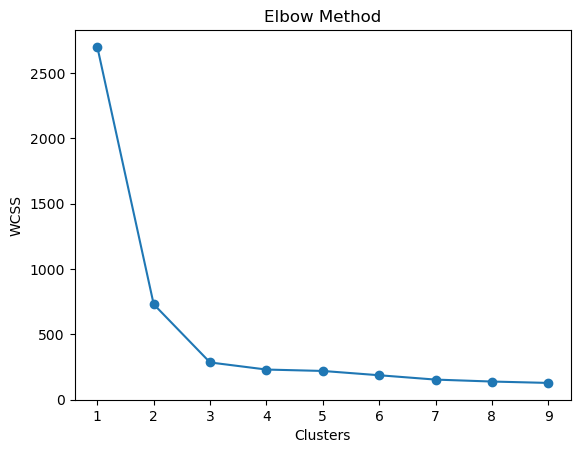

In [61]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

# 10.Apply K-Means

In [62]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


## 11.Visualize Clusters

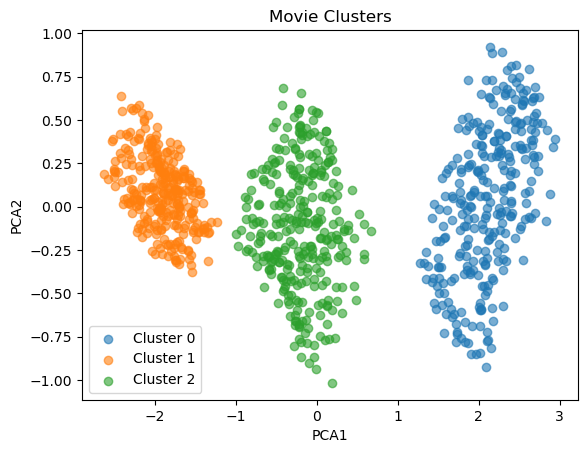

In [63]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

df['pca1'] = pca_features[:, 0]
df['pca2'] = pca_features[:, 1]

plt.figure()

for i in range(3):
    subset = df[df['cluster'] == i]
    plt.scatter(subset['pca1'], subset['pca2'], label=f"Cluster {i}", alpha=0.6)

plt.legend()
plt.title("Movie Clusters")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

## CLUSTER CENTERS

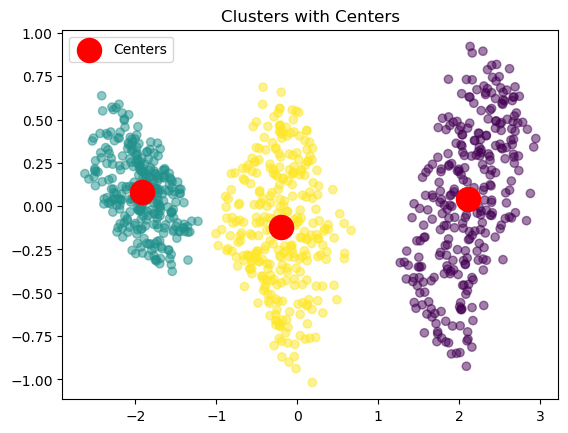

In [64]:
centers = kmeans.cluster_centers_

plt.figure()

plt.scatter(df['pca1'], df['pca2'], c=df['cluster'], alpha=0.5)
plt.scatter(pca.transform(centers)[:,0], pca.transform(centers)[:,1],
            s=300, c='red', label='Centers')

plt.legend()
plt.title("Clusters with Centers")
plt.show()

## 12.Recommendation Function

In [65]:
def recommend(movie_name):
    movie = df[df['title'] == movie_name]
    
    if movie.empty:
        return "Movie not found"
    
    cluster = movie['cluster'].values[0]
    
    recommendations = df[df['cluster'] == cluster]
    
    return recommendations['title'].head(10)

In [66]:
print(recommend("Blockbuster_Movie_7"))

3      Blockbuster_Movie_3
7      Blockbuster_Movie_7
11    Blockbuster_Movie_11
12    Blockbuster_Movie_12
15    Blockbuster_Movie_15
18    Blockbuster_Movie_18
21    Blockbuster_Movie_21
24    Blockbuster_Movie_24
27    Blockbuster_Movie_27
36    Blockbuster_Movie_36
Name: title, dtype: str


## Final Conclusion

- The project successfully clusters movies into meaningful groups such as blockbuster, average, and low-performing categories using K-Means clustering. The recommendation system suggests movies from the same cluster, improving content discovery without relying on user history.